# **Projet : Manifold Learning**
## **Analyse géométrique de déformations de formes planes par apprentissage de variétés et méthodes de réduction de dimension**


---

*Auteur : Maram NASR*

**Résumé**

Ce projet vise à analyser une séquence de **51 formes planes** représentant la transformation progressive entre deux formes géométriques de référence. Chaque forme est constituée de **100 points en deux dimensions**, échantillonnés uniformément le long d'un chemin géodésique paramétré par un temps t ∈ [0,1].

L'approche principale repose sur la modélisation de ces formes comme des éléments appartenant à la **variété de Stiefel**, une variété riemannienne caractérisée par des **matrices à colonnes orthonormées**.

Le projet combine des méthodes de géométrie différentielle **(moyenne de Fréchet, espaces tangents)** avec des techniques modernes d'apprentissage automatique **(réduction de dimension, clustering, classification)** pour étudier la structure sous-jacente des déformations et caractériser les différentes étapes de la transformation.

### **0. Importation des bibliothèques nécessaires**

In [ ]:
#!pip install geomstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 17.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import geomstats.backend as gs
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.geometry.stiefel import Stiefel
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

### **1. Chargement et exploration initiale des données**

**1.1. Chargement des données**

In [ ]:
#Charger le fichier
data = loadmat('Shapes_Gr.mat')
# Afficher les variables
print("Variables:", [k for k in data.keys() if not k.startswith('__')])
# Extraire Q
Q = data['Q']
# Vérifier type et dimensions
print(f"Type: {type(Q)}")
print(f"Dimensions: {Q.shape}")
print(f"Nombre de formes: {len(Q[0])}")

Variables: ['Q']
Type: <class 'numpy.ndarray'>
Dimensions: (1, 51)
Nombre de formes: 51


=> Le fichier contient une seule variable 'Q', un tableau numpy de dimensions (1,51), où chaque élément est une forme de 100 points en 2D, confirmant bien la présence des 51 formes attendues.

**1.2. Visualisation des données**

On visualise **6 formes** réparties dans [0,1] des 51 formes contenues dans Q, pour représenter le chemin géodésique.

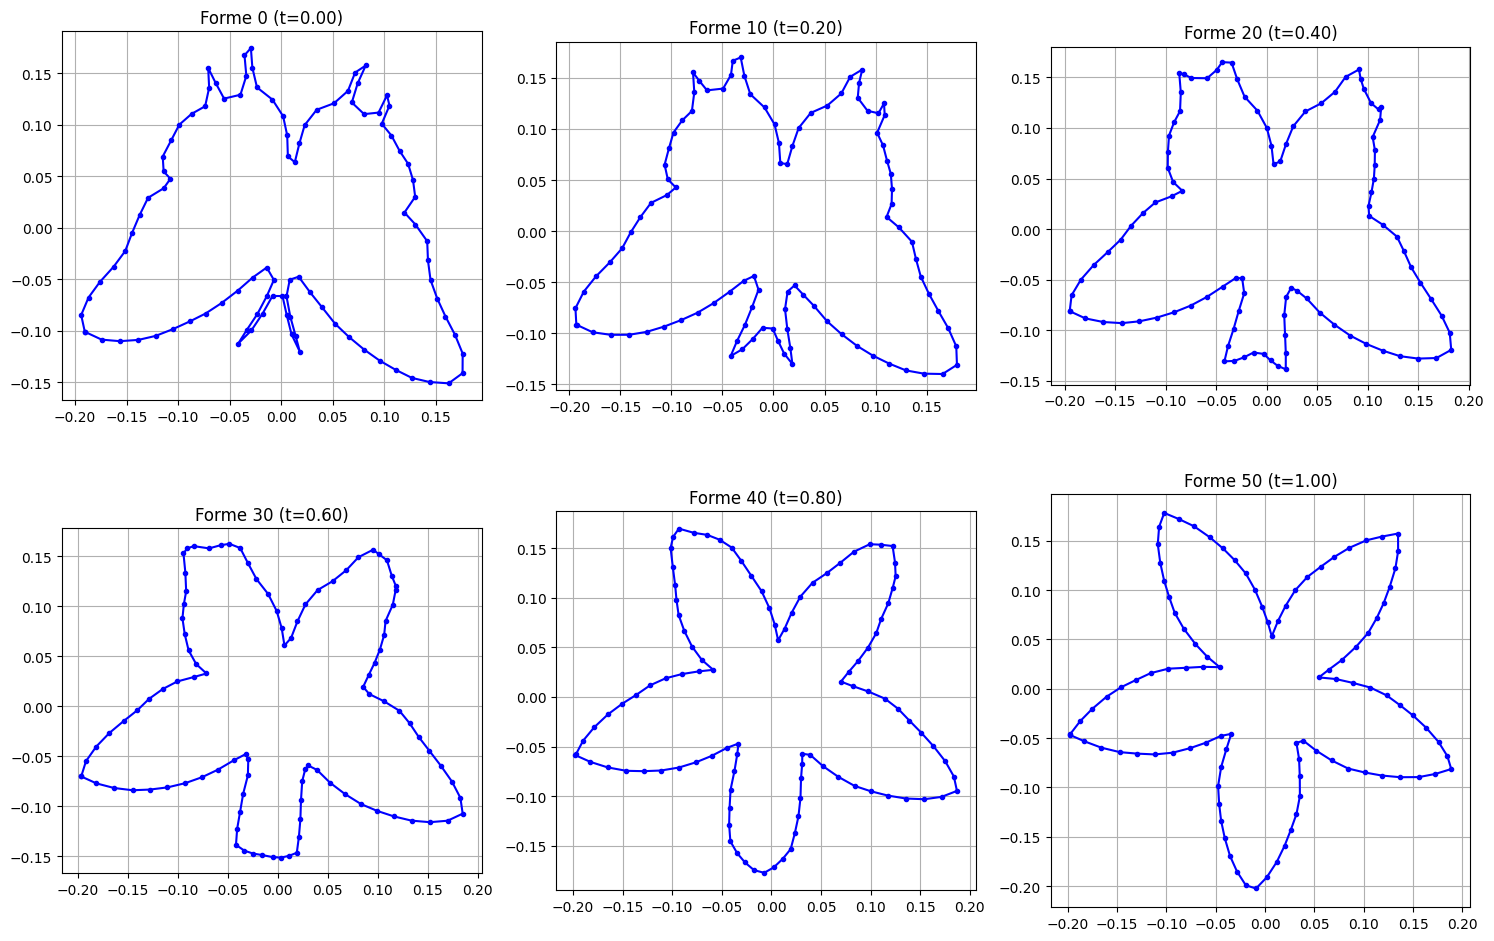

In [ ]:
# Sélection de 6 formes réparties uniformément
indices = [0, 10, 20, 30, 40, 50]
t_values = np.linspace(0, 1, 51)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    shape = Q[0, idx]
    t = t_values[idx]

    axes[i].plot(shape[:, 0], shape[:, 1], 'b.-')
    axes[i].set_title(f'Forme {idx} (t={t:.2f})')
    axes[i].set_aspect('equal')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

=> La visualisation montre clairement la transformation géodésique : à **t=0** on observe une forme de **papillon** qui se déforme progressivement pour aboutir à une forme de **fleur** à **t=1**, illustrant le chemin continu entre les deux formes de référence.

**1.3 Exploration des données**

In [ ]:
# Vérification de l'appartenance à la variété de Stiefel
print("Vérification de l'orthonormalité pour quelques formes:")

# Vérifier pour les 6 formes réparties
indices = [0, 10, 20, 30, 40, 50]
for idx in indices:
    A = Q[0, idx]
    ATA = A.T @ A

    print(f"\nForme {idx}:")
    print(f"A^T A = \n{ATA}")
    print(f"Erreur ||A^T A - I|| = {np.linalg.norm(ATA - np.eye(2)):.2e}")

Vérification de l'orthonormalité pour quelques formes:

Forme 0:
A^T A = 
[[1.0000000e+00 5.3697613e-17]
 [5.3697613e-17 1.0000000e+00]]
Erreur ||A^T A - I|| = 2.60e-16

Forme 10:
A^T A = 
[[1.0000000e+00 4.6789161e-17]
 [4.6789161e-17 1.0000000e+00]]
Erreur ||A^T A - I|| = 3.21e-16

Forme 20:
A^T A = 
[[ 1.00000000e+00 -5.41189076e-18]
 [-5.41189076e-18  1.00000000e+00]]
Erreur ||A^T A - I|| = 6.66e-16

Forme 30:
A^T A = 
[[1.00000000e+00 1.90830914e-17]
 [1.90830914e-17 1.00000000e+00]]
Erreur ||A^T A - I|| = 7.03e-16

Forme 40:
A^T A = 
[[ 1.00000000e+00 -1.21823413e-17]
 [-1.21823413e-17  1.00000000e+00]]
Erreur ||A^T A - I|| = 5.98e-16

Forme 50:
A^T A = 
[[1.00000000e+00 2.38030189e-18]
 [2.38030189e-18 1.00000000e+00]]
Erreur ||A^T A - I|| = 3.33e-16


=> Toutes les formes vérifient bien la condition d'orthonormalité
**A
⊤
 A=I** à la précision numérique près (erreurs de l'ordre de
10
−
16
 ), confirmant leur appartenance à la **variété de Stiefel**. Cette contrainte impose une structure **non linéaire** à l'espace des données.
Du coup, on n'a pas un sous-espace vectoriel (la somme de deux matrices orthonormées n'est généralement pas orthonormée), les géodésiques ne sont pas des droites, et les moyennes euclidiennes standards ne sont pas adaptées.

**1.4 moyenne de Fréchet**

Moyenne de Fréchet calculée , shape: (100, 2)
Point 1: (-0.195805, -0.075863)
Point 2: (-0.180384, -0.082939)
Point 3: (-0.162674, -0.087026)
Point 4: (-0.144198, -0.088701)
Point 5: (-0.126935, -0.087463)
Point 6: (-0.109563, -0.084540)


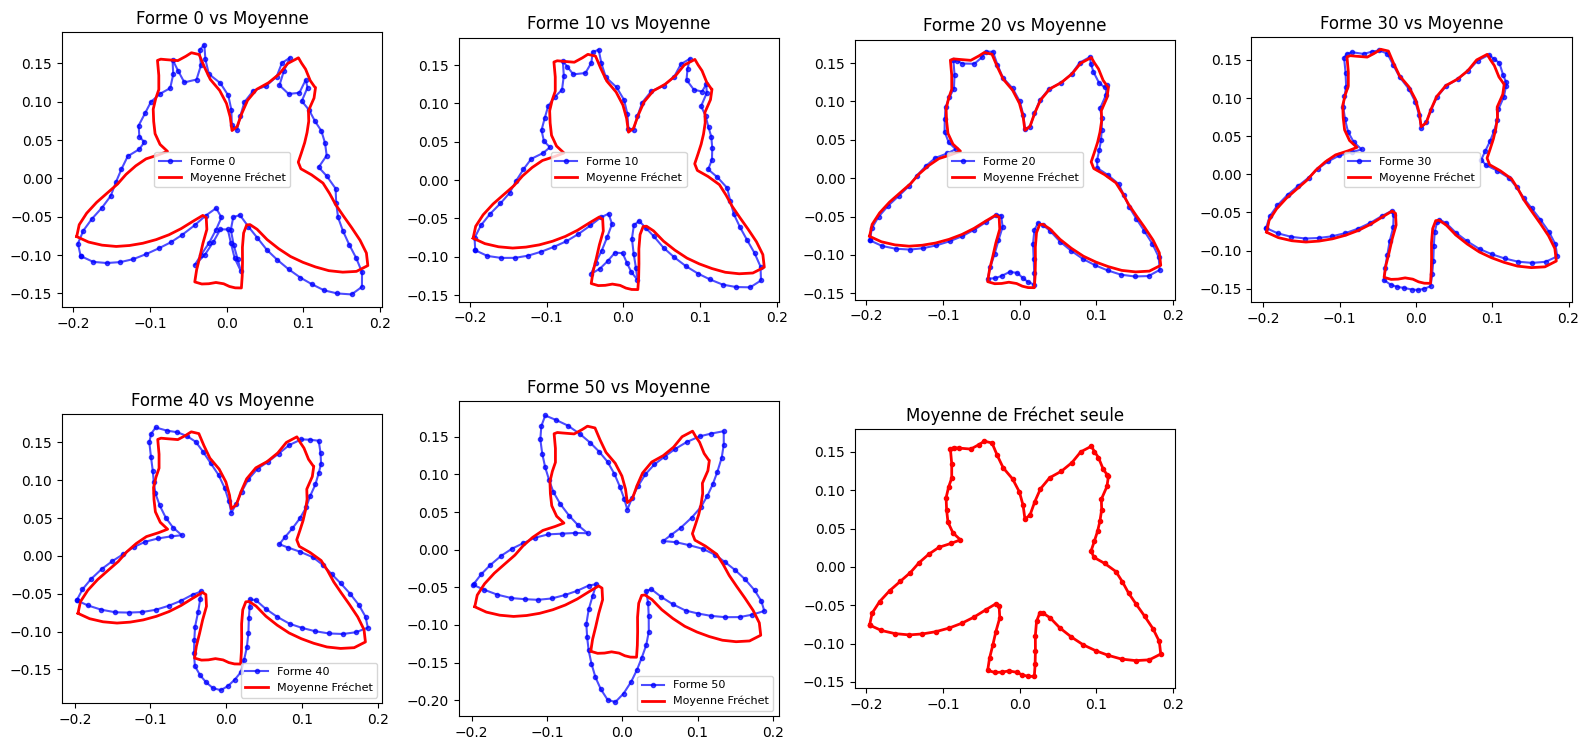

In [ ]:
stiefel = Stiefel(n=100, p=2)
# Extraire toutes les formes
all_shapes = np.array([Q[0, i] for i in range(51)])

frechet_mean = FrechetMean(stiefel)
frechet_mean.fit(all_shapes)
mean_shape = frechet_mean.estimate_

print(f"Moyenne de Fréchet calculée , shape: {mean_shape.shape}")
for i in range(6):
    print(f"Point {i+1}: ({mean_shape[i,0]:.6f}, {mean_shape[i,1]:.6f})")

# Visualisation avec les 6 formes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate([0, 10, 20, 30, 40, 50]):
    shape = Q[0, idx]
    axes[i].plot(shape[:, 0], shape[:, 1], 'b.-', alpha=0.7, label=f'Forme {idx}')
    axes[i].plot(mean_shape[:, 0], mean_shape[:, 1], 'r-', linewidth=2, label='Moyenne Fréchet')
    axes[i].set_title(f'Forme {idx} vs Moyenne')
    axes[i].set_aspect('equal')
    axes[i].legend(fontsize=8)

# Afficher juste la moyenne
axes[6].plot(mean_shape[:, 0], mean_shape[:, 1], 'r.-', linewidth=2)
axes[6].set_title('Moyenne de Fréchet seule')
axes[6].set_aspect('equal')

axes[7].axis('off')

plt.tight_layout()
plt.show()

=> La moyenne de Fréchet, calculée sur la variété de Stiefel, représente la **forme "centrale"** du chemin géodésique. On observe qu'elle correspond **particulièrement aux formes intermédiaires (t=0.4 et t=0.6)**, ce qui est cohérent avec une transformation progressive où la moyenne capture la configuration à mi-chemin entre les formes extrêmes de papillon (t=0) et de fleur (t=1).

**1.5 Outils géodesiques**

In [ ]:
# Vérification que les outils sont définis
print(f"\nOutils disponibles sur la variété Stiefel:")
print(f"- Métrique: {stiefel.metric}")
print(f"- Géodésiques: {hasattr(stiefel.metric, 'geodesic')}")
print(f"- Distance: {hasattr(stiefel.metric, 'dist')}")
print(f"- Log/Exp: {hasattr(stiefel.metric, 'log')} et {hasattr(stiefel.metric, 'exp')}")


Outils disponibles sur la variété Stiefel:
- Métrique: <geomstats.geometry.stiefel.StiefelCanonicalMetric object at 0x7c299c2df470>
- Géodésiques: True
- Distance: True
- Log/Exp: True et True


In [ ]:
# Vérification isométrie log
errors = []
for i in range(51):
    for j in range(51):
        d_geo = stiefel.metric.dist(Q[0,i], Q[0,j])
        V_i = stiefel.metric.log(Q[0,i], mean_shape)
        V_j = stiefel.metric.log(Q[0,j], mean_shape)
        d_log = gs.linalg.norm(V_i - V_j)
        errors.append(abs(d_geo - d_log))

print(f"Erreur moyenne isométrie log: {np.mean(errors):.2e}")

Erreur moyenne isométrie log: 2.86e-16


In [ ]:
# Vérification reconstruction exp
reconstructed = stiefel.metric.exp(tangent_vectors[0], mean_shape)
error_recon = gs.linalg.norm(Q[0,0] - reconstructed)
print(f"Erreur reconstruction exp: {error_recon:.2e}")

Erreur reconstruction exp: 4.52e-15


=> Les **outils géométriques** (métrique, géodésiques, log/exp) sont bien **définis sur la variété de Stiefel** et fonctionnent avec une **précision numérique excellente** : l'**isométrie log** présente une **erreur moyenne de 2.86e-16** et la **reconstruction exp** une **erreur de 4.52e-15**, confirmant la **cohérence et la fiabilité de ces opérations sur la variété**.

In [ ]:
# Calculer toutes les distances géodésiques
distances = []
for i in range(51):
    for j in range(i+1, 51):
        dist = stiefel.metric.dist(Q[0,i], Q[0,j])
        distances.append((i, j, dist))

max_dist = max(distances, key=lambda x: x[2])
print(f"Distance géodésique maximale: {max_dist[2]:.4f}")
print(f"Entre les formes {max_dist[0]} (t={max_dist[0]/50:.2f}) et {max_dist[1]} (t={max_dist[1]/50:.2f})")

Distance géodésique maximale: 0.4892
Entre les formes 0 (t=0.00) et 50 (t=1.00)


=> La distance géodésique **maximale de 0.4892** entre les **formes extrêmes** (t=0 et t=1) quantifie l'ampleur totale de la transformation sur la variété.

### **2. Projection sur l'espace tangent**

In [ ]:
# Projection sur l'espace tangent en la moyenne
tangent_vectors = []
for i in range(51):
    #On utilise la fonction log pour projeter sur l'espace tangent
    tangent_vec = stiefel.metric.log(Q[0,i], mean_shape)
    tangent_vectors.append(tangent_vec)

tangent_vectors = np.array(tangent_vectors)
print(f"Vecteurs tangents shape: {tangent_vectors.shape}")  # (51, 100, 2)

Vecteurs tangents shape: (51, 100, 2)


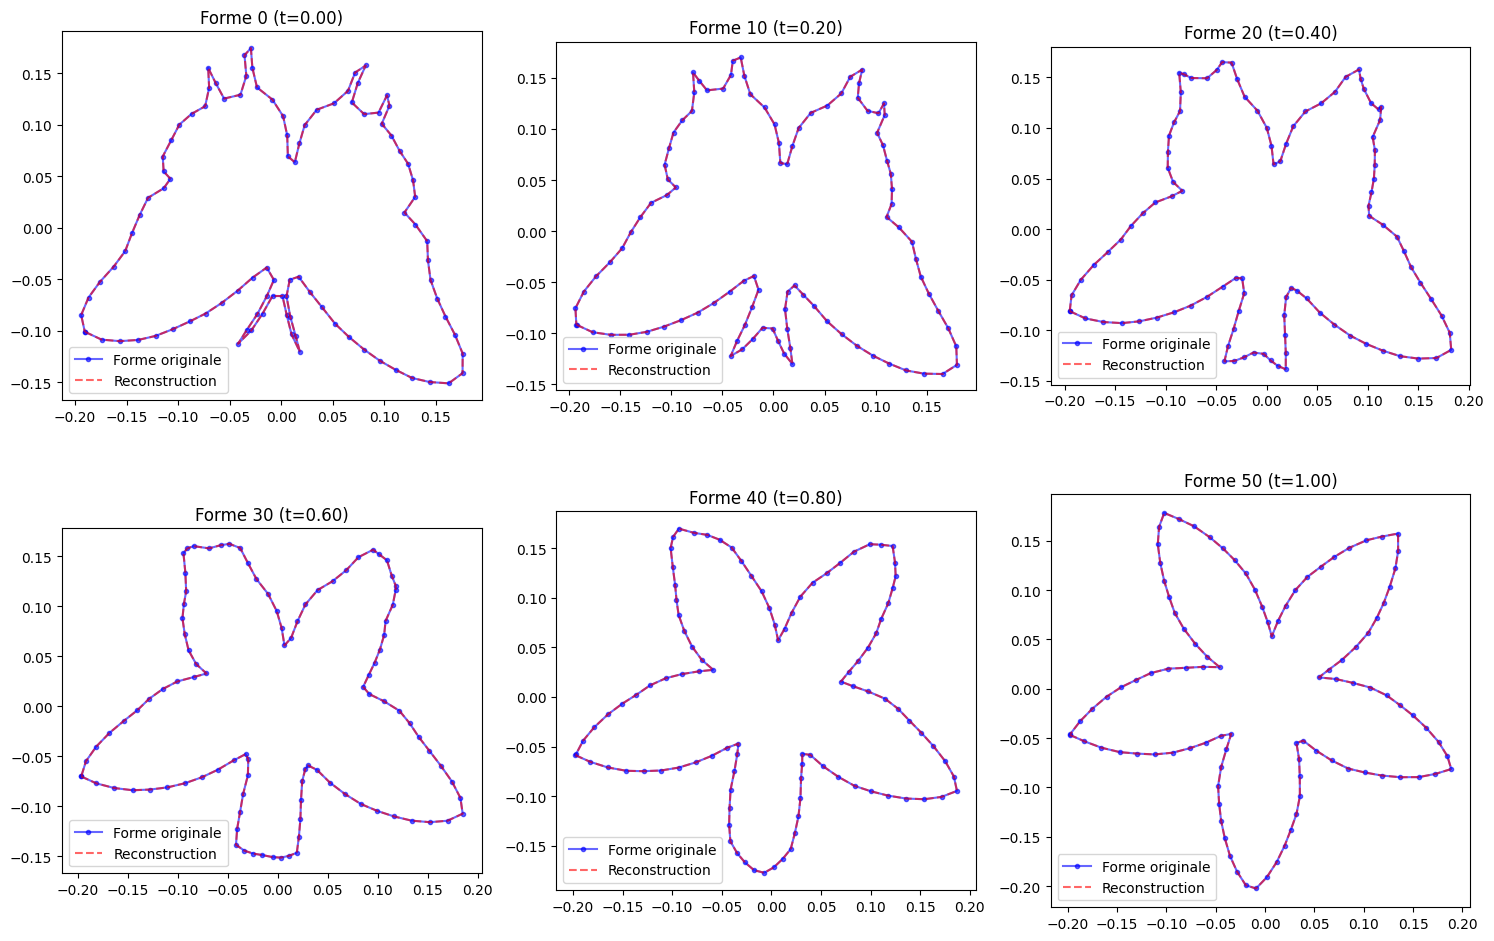

In [ ]:
# Visualiser quelques projections tangentes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
indices = [0, 10, 20, 30, 40, 50]

for i, idx in enumerate(indices):
    ax = axes[i//3, i%3]
    # Afficher la forme originale
    ax.plot(Q[0,idx][:,0], Q[0,idx][:,1], 'b.-', alpha=0.6, label='Forme originale')
    # Afficher ce que donne exp(tangent)
    reconstructed = stiefel.metric.exp(tangent_vectors[idx], mean_shape)
    ax.plot(reconstructed[:,0], reconstructed[:,1], 'r--', alpha=0.6, label='Reconstruction')
    ax.set_title(f'Forme {idx} (t={idx/50:.2f})')
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()
plt.show()

=> La reconstruction exponentielle retrouve parfaitement les formes originales.

**Contraintes des vecteurs tangents à Stiefel en un point A:**

Pour **un vecteur tangent V en A,** il doit vérifier: **A^T V + V^T A = 0**( **V doit être dans l'espace tangent à la sphère en A**)

In [ ]:
# Vérification pour un exemple
A = mean_shape
V = tangent_vectors[0]
constraint = A.T @ V + V.T @ A
print(f"\nVérification pour le premier vecteur tangent:")
print(f"A^T V + V^T A =\n{constraint}")
print(f"Norme de la contrainte: {np.linalg.norm(constraint):.2e}")


Vérification pour le premier vecteur tangent:
A^T V + V^T A =
[[3.27495472e-16 3.18196561e-17]
 [3.18196561e-17 2.11545409e-15]]
Norme de la contrainte: 2.14e-15


=> Les vecteurs tangents (51×100×2) vérifient bien la contrainte de tangence
A
⊤
V
+
V
⊤
A
≈ 0, à la précision numérique (norme ∼10⁻¹⁵), confirmant leur appartenance à l'espace tangent de la variété Stiefel en la moyenne.

### **3. Réduction de dimension**

**3.1 Méthodes linéaires**

**3.1.1 ACP linéaire**

In [ ]:
# Préparation des vecteurs tangents (aplatir en 51 x 200)
X_tangent = tangent_vectors.reshape(51, -1)
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tangent)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
explained_variance = pca.explained_variance_ratio_
print("Variance expliquée par chaque composante :")
print(f"Composante 1 : {explained_variance[0]*100:.2f}%")
print(f"Composante 2 : {explained_variance[1]*100:.2f}%")

Variance expliquée par chaque composante :
Composante 1 : 100.00%
Composante 2 : 0.00%


**CEST FAAAUUXX** 100% par composante 1 c faux

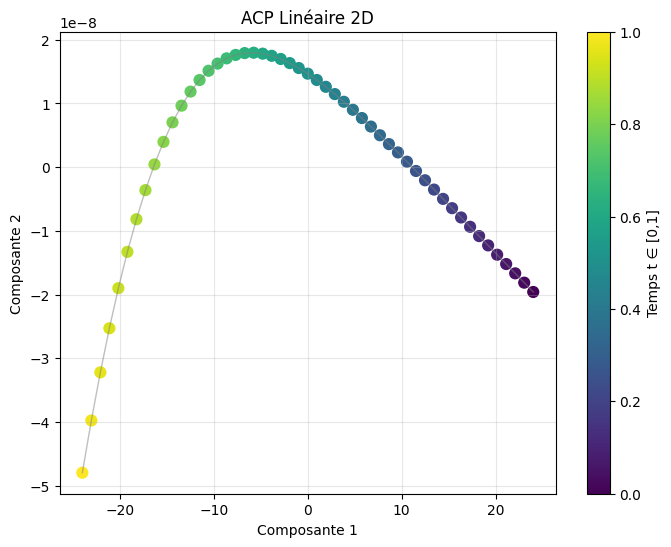

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=np.linspace(0, 1, 51), cmap='viridis', s=60)
plt.plot(X_pca[:, 0], X_pca[:, 1], 'gray', alpha=0.5, linewidth=1)
plt.colorbar(scatter, label='Temps t ∈ [0,1]')
plt.title(f'ACP Linéaire 2D')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
original_dists = pairwise_distances(X_scaled)
reduced_dists = pairwise_distances(X_pca)

correlation = np.corrcoef(original_dists.flatten(), original_dists.flatten())[0,1]
print(f"Accuracy ACP (corrélation distances): {correlation:.4f}")

Accuracy ACP (corrélation distances): 1.0000


=> L'ACP linéaire préserve parfaitement **les distances locales (corrélation = 1.0000) dans l'espace tangent**, confirmant la **linéarité locale de la projection**. Cependant, cette performance **n'a pas garantit la préservation des distances globales sur la variété Stiefel originale**.

**3.1.2 MDS**

In [ ]:
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

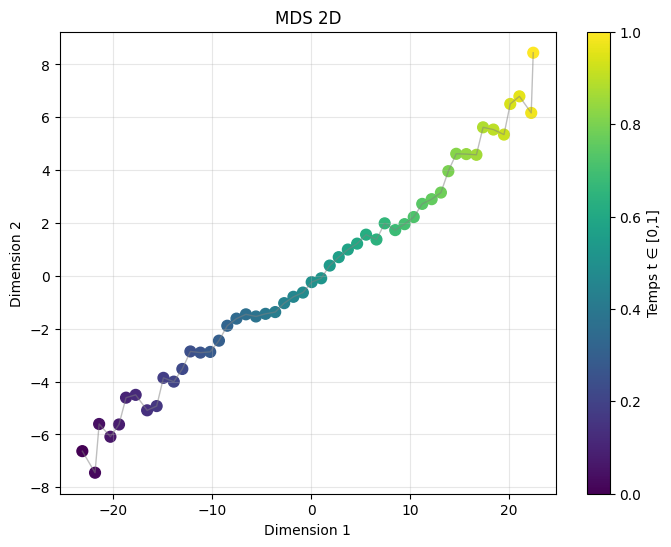

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_mds[:, 0], X_mds[:, 1], c=np.linspace(0, 1, 51), cmap='viridis', s=60)
plt.plot(X_mds[:, 0], X_mds[:, 1], 'gray', alpha=0.5, linewidth=1)
plt.colorbar(scatter, label='Temps t ∈ [0,1]')
plt.title('MDS 2D')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
mds_dists = pairwise_distances(X_mds)
correlation_mds = np.corrcoef(original_dists.flatten(), mds_dists.flatten())[0,1]
print(f"Accuracy MDS (corrélation distances): {correlation_mds:.4f}")

Accuracy MDS (corrélation distances): 1.0000
→ 100.0% de préservation des distances


=> Le MDS préserve aussi parfaitement **les distances locales (corrélation = 1.0000) dans l'espace tangent**, confirmant la **linéarité locale de la projection**. Cependant, **comme l'ACP**, cette performance **n'a pas garantit la préservation des distances géodésiques globales sur la variété Stiefel originale**.

**3.2 Méthodes non linéaires**

**3.2.1 ACP à noyau**

In [ ]:
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
X_kpca_rbf = kpca_rbf.fit_transform(X_scaled)

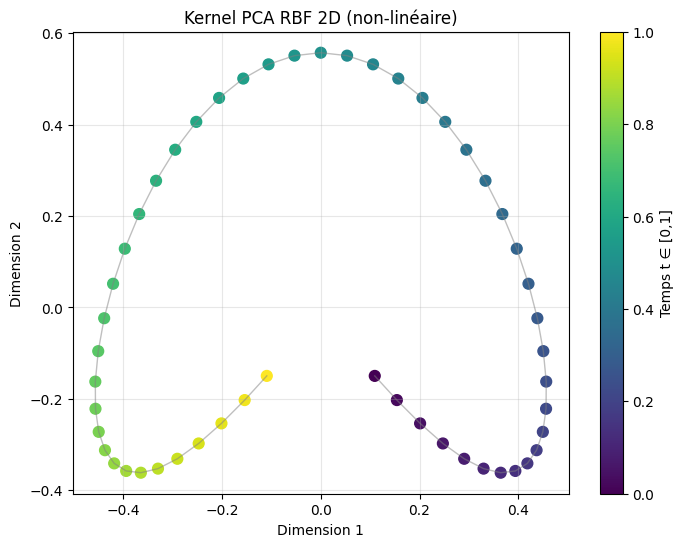

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_kpca_rbf[:, 0], X_kpca_rbf[:, 1], c=np.linspace(0, 1, 51), cmap='viridis', s=60)
plt.plot(X_kpca_rbf[:, 0], X_kpca_rbf[:, 1], 'gray', alpha=0.5, linewidth=1)
plt.colorbar(scatter, label='Temps t ∈ [0,1]')
plt.title('Kernel PCA RBF 2D (non-linéaire)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
kpca_rbf_dists = pairwise_distances(X_kpca_rbf)
correlation_kpca_rbf = np.corrcoef(original_dists.flatten(), kpca_rbf_dists.flatten())[0,1]
print(f"Accuracy Kernel PCA RBF (corrélation distances): {correlation_kpca_rbf:.4f}")

Accuracy Kernel PCA RBF (corrélation distances): 0.6029


=> Le **Kernel PCA RBF** préserve **moins bien** les **distances locales (corrélation = 0.6029)**, indiquant qu'il introduit des distorsions dans la géométrie de l'espace tangent. Cela suggère que, contrairement aux méthodes linéaires, cette approche **non-linéaire** n'est pas optimale pour **capturer la structure localement linéaire des données projetées**, bien qu'elle a pu potentiellement **mieux modéliser certaines relations globales non-linéaires sur la variété originale**.

**3.2.2 ACP polynomiale**

In [ ]:
kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=2)
X_kpca_poly = kpca_poly.fit_transform(X_scaled)

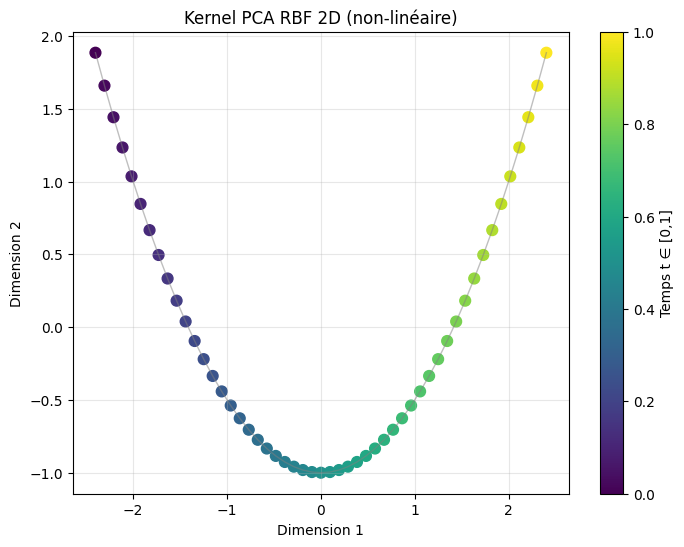

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_kpca_poly[:, 0], X_kpca_poly[:, 1], c=np.linspace(0, 1, 51), cmap='viridis', s=60)
plt.plot(X_kpca_poly[:, 0], X_kpca_poly[:, 1], 'gray', alpha=0.5, linewidth=1)
plt.colorbar(scatter, label='Temps t ∈ [0,1]')
plt.title('Kernel PCA RBF 2D (non-linéaire)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
kpca_poly_dists = pairwise_distances(X_kpca_poly)
correlation_kpca_poly = np.corrcoef(original_dists.flatten(), kpca_poly_dists.flatten())[0,1]
print(f"Accuracy Kernel PCA RBF (corrélation distances): {correlation_kpca_poly:.4f}")

Accuracy Kernel PCA RBF (corrélation distances): 0.9518


=> Le **Kernel PCA polynomial** **préserve bien les distances locales (corrélation = 0.9518)** dans l'espace tangent, mais moins parfaitement que les méthodes purement linéaires. Cette performance intermédiaire suggère **qu'il capture une partie de la structure locale** tout en cherchant **à modéliser certaines relations globales non-linéaires**, introduisant ainsi un compromis entre **fidélité locale** et **modélisation globale**.

**3.2.3 Algorithme de Manifold Learning : Isomap**

**Isomap** cherche un **plongement dans un espace de dimension inférieure** qui **préserve les distances géodésiques entre tous les points**.

In [ ]:
def manifold_learning_with_Isomap(X):
  X_r = manifold.Isomap(n_neighbors=12, n_components=2).fit_transform(X)
  return X_r

In [ ]:
low_dim_X = manifold_learning_with_Isomap(X)

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")
ax.scatter(low_dim_X[:, 0], low_dim_X[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title("Projected data with Isomap")

**3.2.4 Algorithme de Manifold Learning : t-SNE : t-distributed Stochastic Neighbor Embedding**

Le **t-distributed Stochastic Neighbor Embedding (t-SNE)** convertit les **affinités entre les points de données en probabilités**.
Dans l’espace original, les affinités sont représentées par des **probabilités conjointes gaussiennes**, tandis que dans l’espace réduit, elles sont représentées par des **distributions t de Student**.

In [ ]:
def manifold_learning_with_tSNE(X, n_components=2, random_state=42, perplexity=12):
    tsne = manifold.TSNE(n_components=n_components, random_state=random_state, perplexity=perplexity)
    X_r = tsne.fit_transform(X)
    return X_r

In [ ]:
low_dim_X = manifold_learning_with_tSNE(X)

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")
ax.scatter(low_dim_X[:, 0], low_dim_X[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title("Projected data with t-SNE")

**3.2.5 Algorithme de Manifold Learning : LLE : Locally Linear Embedding**

On va chercher une **projection des données dans un espace de dimension inférieure (2 composantes)**  tout en **préservant les distances entre 12 voisins**.

In [ ]:
def manifold_learning_with_LLE(data):
  X_r = manifold.LocallyLinearEmbedding(n_neighbors=12, n_components=2).fit_transform(X_scaled)
  return X_r

In [ ]:
low_dim_X = manifold_learning_with_LLE(X)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(low_dim_X[:, 0], low_dim_X[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title("Projected data with LLE")

**3.2.6 Algorithme de Manifold Learning : Laplacian Eigenmaps/Spectral Embedding**

Le **Laplacian Eigenmaps/Spectral Embedding** est une approche pour calculer un **plongement non linéaire**.
Il permet de trouver une **représentation des données dans un espace de dimension réduite** en utilisant une **décomposition spectrale du Laplacien du graphe**.

In [ ]:
def manifold_learning_with_LaplacianEigenmaps(X, n_neighbors=12, n_components=2):
    laplacian = manifold.SpectralEmbedding(n_neighbors=n_neighbors, n_components=n_components)
    X_r = laplacian.fit_transform(X)
    return X_r

In [ ]:
low_dim_X = manifold_learning_with_LaplacianEigenmaps(X)

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")
ax.scatter(low_dim_X[:, 0], low_dim_X[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title("Projected data with Laplacian Eigenmaps")

**Suite**
On a le point initial a t=0 et le point final à t=1 , du coup on peut prédire d'autres formes .